In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 891
Number of columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Categorical Features: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


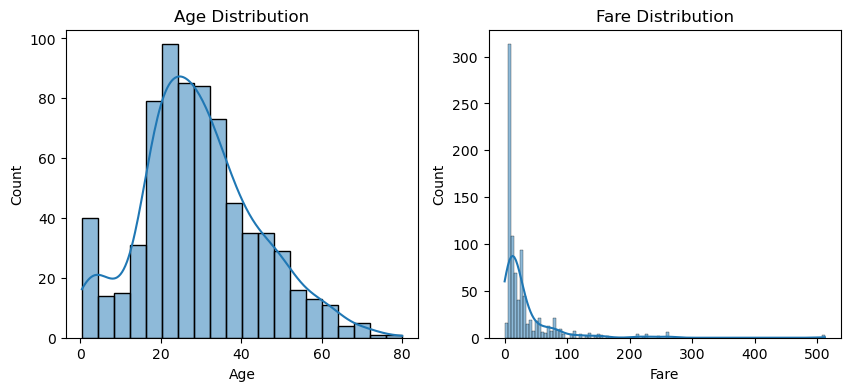

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")

plt.show()

In [7]:
df = df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1)

In [8]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [12]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [14]:
basic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [15]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [16]:
pipeline_fs = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif, k=5)),
    ("model", LogisticRegression(max_iter=1000))
])

In [17]:
pipeline_poly = Pipeline([
    ("preprocessing", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LogisticRegression(max_iter=1000))
])

In [18]:
pipeline_pca = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression())
])

In [19]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = pipeline.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


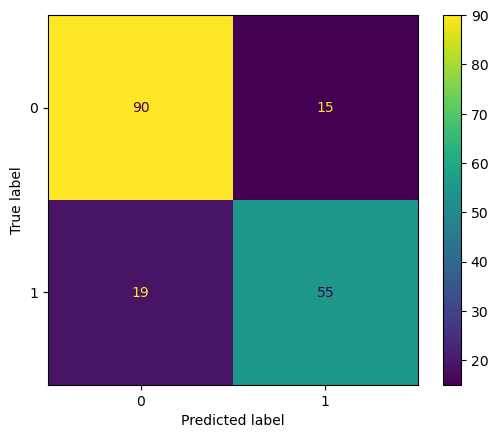

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()


In [23]:
scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())

Cross Validation Scores: [0.77653631 0.78651685 0.78089888 0.76966292 0.8258427 ]
Mean CV Score: 0.7878915322327538


In [24]:
print("Train-Test Accuracy:", accuracy)
print("Cross Validation Mean:", scores.mean())

Train-Test Accuracy: 0.8100558659217877
Cross Validation Mean: 0.7878915322327538


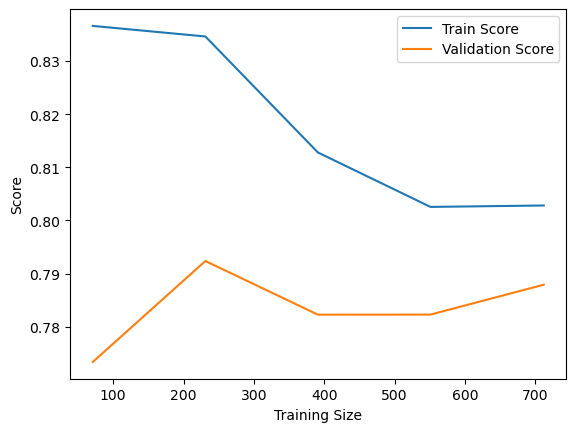

In [25]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")

plt.legend()
plt.show()

In [26]:
param_grid = {
    "model__C":[0.01,0.1,1,10],
    "model__solver":["lbfgs","liblinear"]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best Score: 0.7963065103910174


In [27]:
param_dist = {
    "model__C": np.logspace(-3,3,10),
    "model__solver":["lbfgs","liblinear"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Best Params: {'model__solver': 'liblinear', 'model__C': 0.021544346900318832}


In [28]:
print("GridSearch Score:", grid.best_score_)
print("RandomSearch Score:", random_search.best_score_)

GridSearch Score: 0.7963065103910174
RandomSearch Score: 0.7991037131882202


In [30]:
class AgeGroupTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["AgeGroup"] = pd.cut(
            X["Age"],
            bins=[0,18,40,60,100],
            labels=["Child","Adult","Middle","Senior"]
        )
        return X

In [31]:
def log_transform(x):
    return np.log1p(x)

log_transformer = FunctionTransformer(log_transform)

In [32]:
union = FeatureUnion([
    ("pca", PCA(n_components=2)),
    ("select", SelectKBest(k=2))
])

In [33]:
nested_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("features", union),
    ("model", RandomForestClassifier())
])

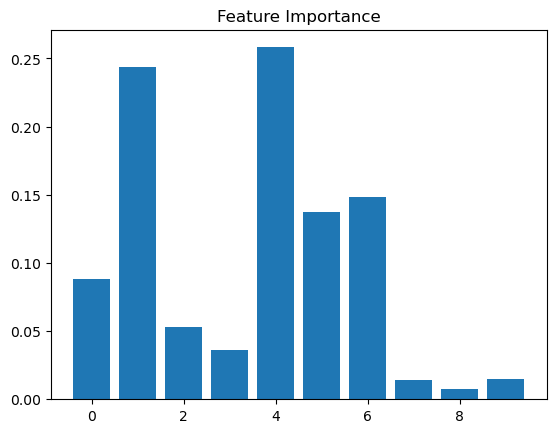

In [34]:
rf = RandomForestClassifier()

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf)
])

rf_pipeline.fit(X_train, y_train)

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")

plt.show()

C:\Users\gsrav\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


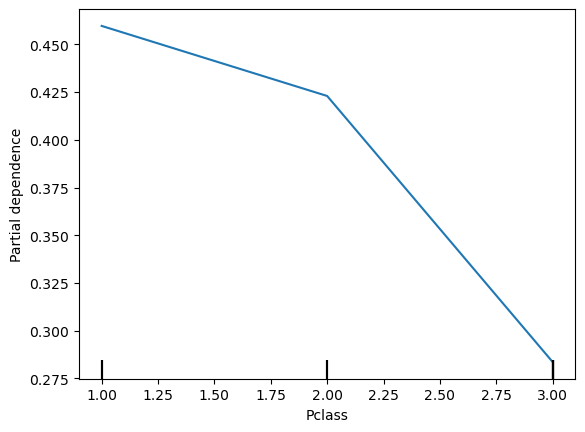

In [35]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    rf_pipeline,
    X_train,
    features=[0]
)

plt.show()

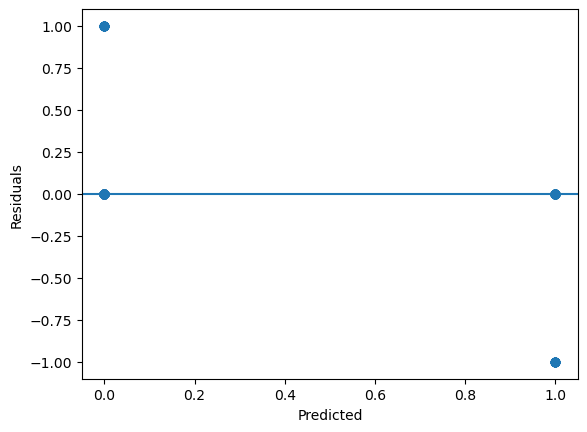

In [36]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.axhline(y=0)

plt.show()